1. Khai báo thư viện và Cài đặt
Trước tiên, cài đặt và import các thư viện cần thiết cho việc phân tích, dự báo và xử lý dữ liệu.

In [4]:
# Cài đặt các thư viện cần thiết
!pip install pandas matplotlib statsmodels prophet causalimpact tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings

# Tắt các cảnh báo không cần thiết
warnings.filterwarnings('ignore')

2. Đọc và Tiền xử lý dữ liệu:
Thực hiện nạp dữ liệu từ file Excel, chuyển đổi cột ngày tháng và thiết lập chỉ mục (index).

In [5]:
# Đọc dữ liệu từ file Excel
data = pd.read_csv('/content/GOOGL_stock.csv', skiprows=3)

data.columns = ['Date','Close','High','Low','Open','Volume']

# Chuyển đổi cột 'Date' sang định dạng datetime
data['Date'] = pd.to_datetime(data['Date'])

# Thiết lập cột 'Date' làm chỉ mục cho DataFrame
data.set_index('Date', inplace=True)

data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2021-03-10,101.046036,102.297081,100.209355,102.297081,27100000
2021-03-11,104.239395,104.771871,102.051429,102.139266,27702000
2021-03-12,101.731346,103.101494,100.858940,103.041947,33818000
2021-03-15,101.951675,101.978966,100.629171,101.482223,26168000
2021-03-16,103.413147,104.891472,102.192367,102.524854,31900000


In [6]:
# Kiểm tra dữ liệu thiếu và mô tả dữ liệu
print("Thống kê mô tả dữ liệu:")
print(data.describe())

print("\nKiểm tra dữ liệu thiếu:")
data.isnull().sum()

Thống kê mô tả dữ liệu:
             Close         High          Low         Open        Volume
count  1254.000000  1254.000000  1254.000000  1254.000000  1.254000e+03
mean    153.544798   155.246953   151.733537   153.462627  3.225275e+07
std      55.019941    55.651040    54.267939    55.025859  1.360836e+07
min      82.804359    85.871184    82.715030    84.759574  9.701400e+06
25%     117.635429   118.785244   116.520108   117.609011  2.353710e+07
50%     138.712677   140.066693   137.320681   138.431050  2.901835e+07
75%     170.362877   172.597049   167.843820   169.869362  3.657155e+07
max     343.690002   349.000000   337.470001   347.339996  1.274901e+08

Kiểm tra dữ liệu thiếu:


,0
Close,0
High,0
Low,0
Open,0
Volume,0


PHÂN TÍCH ĐƠN BIẾN

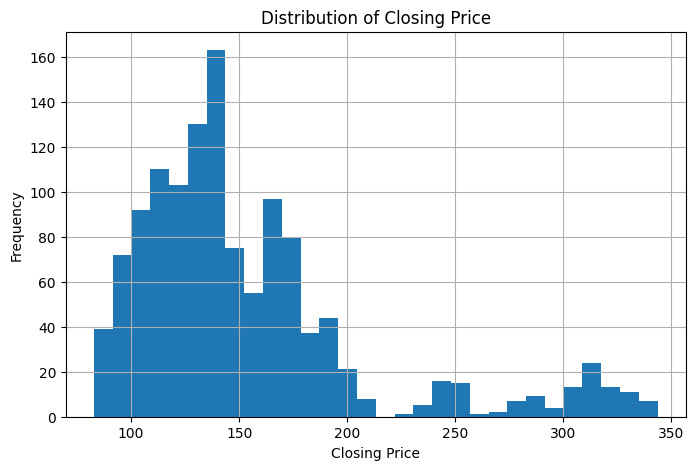

In [7]:
#Histogram - Phân phối dữ liệu. Kiểm tra phân phối của giá đóng cửa.

plt.figure(figsize=(8,5))
data['Close'].hist(bins=30)
plt.title("Distribution of Closing Price")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

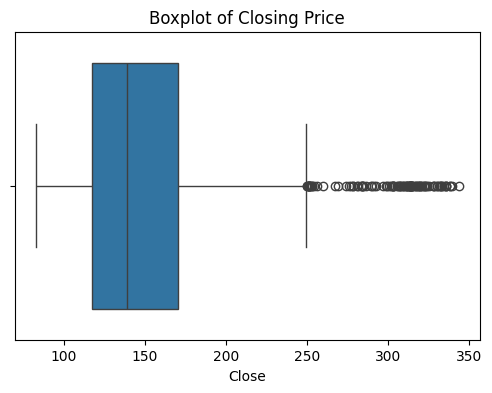

In [8]:
import seaborn as sns
#Boxplot – Phát hiện Outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=data['Close'])
plt.title("Boxplot of Closing Price")
plt.show()

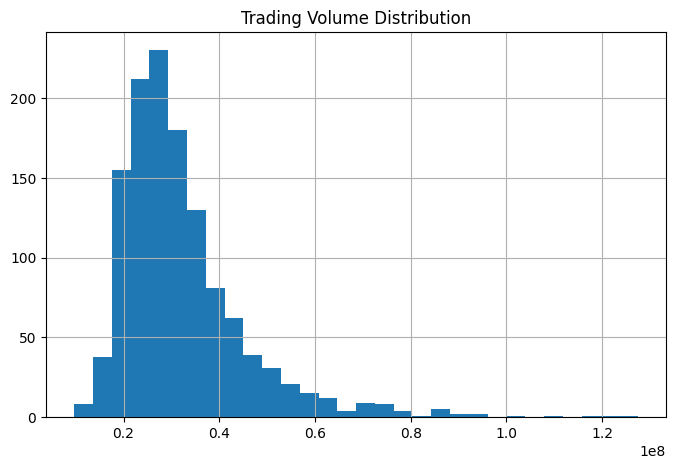

In [9]:
#Volume Distribution
plt.figure(figsize=(8,5))
data['Volume'].hist(bins=30)
plt.title("Trading Volume Distribution")
plt.show()

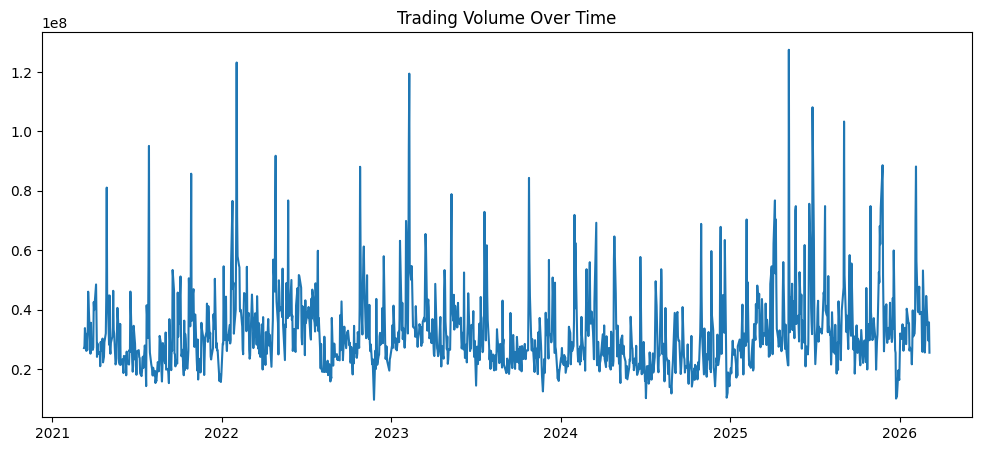

In [10]:
#Khối lượng giao dịch theo thời gian
plt.figure(figsize=(12,5))
plt.plot(data['Volume'])
plt.title("Trading Volume Over Time")
plt.show()

PHÂN TÍCH ĐA BIẾN

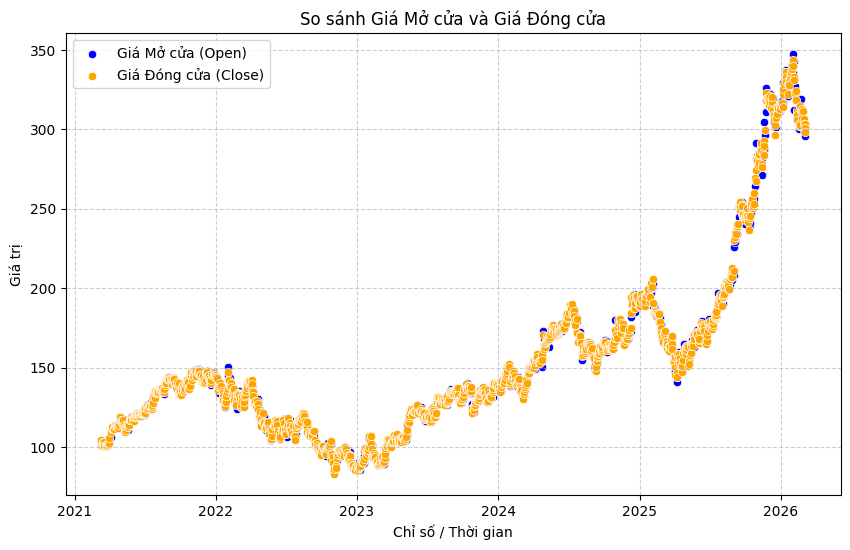

In [11]:
#Scatter Plot (Open vs Close)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Vẽ các điểm của Open (màu xanh dương)
sns.scatterplot(x=data.index, y=data['Open'], color='blue', label='Giá Mở cửa (Open)')

# Vẽ các điểm của Close (màu cam)
sns.scatterplot(x=data.index, y=data['Close'], color='orange', label='Giá Đóng cửa (Close)')

# Thêm tiêu đề và chú thích
plt.title("So sánh Giá Mở cửa và Giá Đóng cửa")
plt.xlabel("Chỉ số / Thời gian")
plt.ylabel("Giá trị")
plt.legend() # Hiển thị bảng ghi chú
plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới cho dễ nhìn
plt.show()

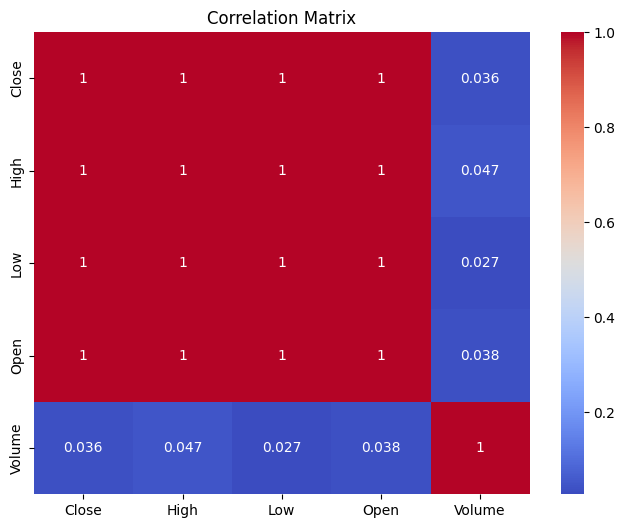

In [12]:
#Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

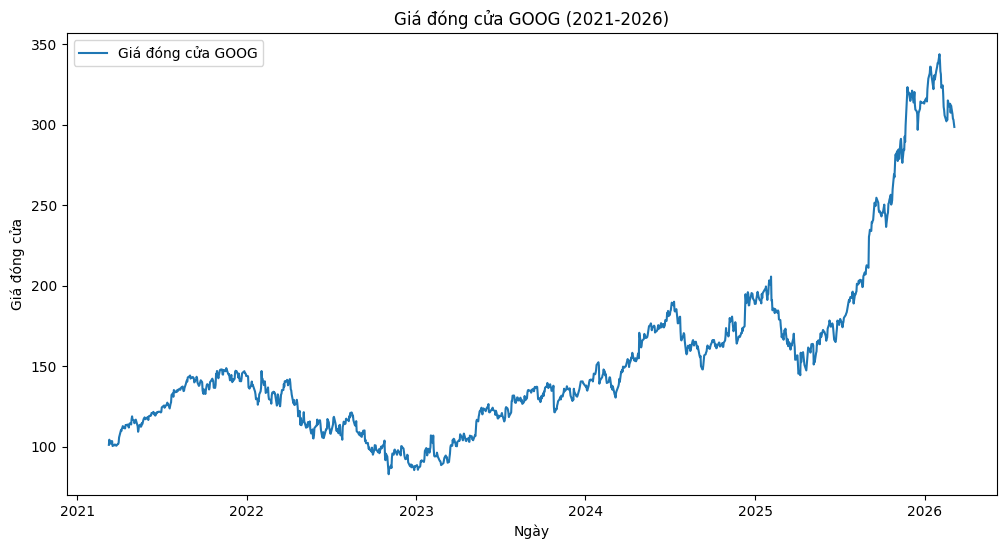

In [13]:
# Phân tích dữ liệu (EDA) đối với phương pháp Time Series Analysis
# Vẽ biểu đồ giá đóng cửa
# Trích xuất cột giá đóng cửa (Close) để phân tích chuỗi thời gian
ts = data['Close']

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ đường biểu diễn giá đóng cửa
plt.plot(ts, label='Giá đóng cửa GOOG')

# Thêm tiêu đề và nhãn cho các trục
plt.title('Giá đóng cửa GOOG (2021-2026)')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa')

# Hiển thị chú thích
plt.legend()

# Hiển thị biểu đồ
plt.show()

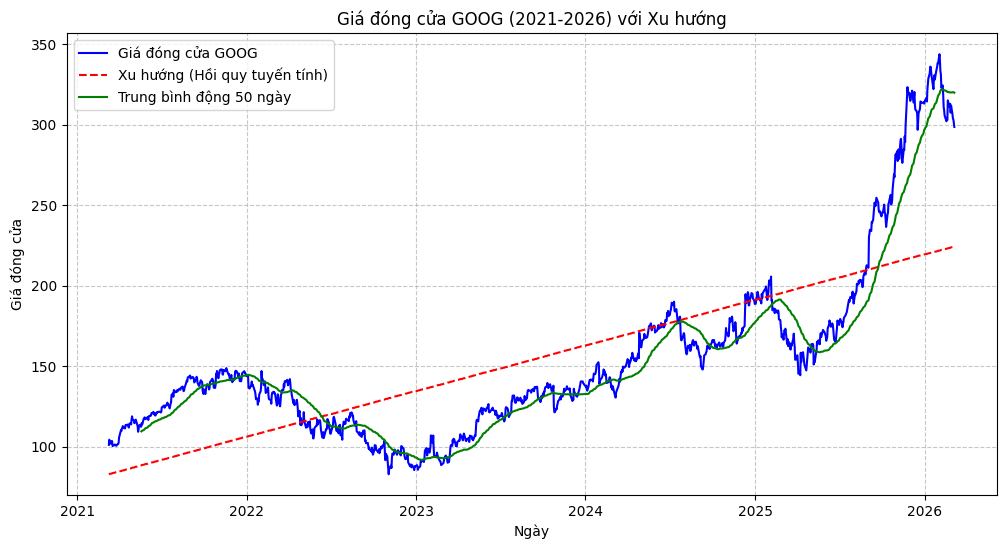

Hệ số xu hướng (slope): 0.1129
Giá trị chặn (intercept): 82.8083


In [14]:
#Phân tích dữ liệu (EDA)
#Vẽ biểu đồ giá đóng cửa với đường xu hướng
from sklearn.linear_model import LinearRegression

# Khởi tạo khung hình
plt.figure(figsize=(12, 6))

# Vẽ giá đóng cửa thực tế
plt.plot(ts, label='Giá đóng cửa GOOG', color='blue')

# --- Thêm đường xu hướng bằng hồi quy tuyến tính ---
X = np.arange(len(ts)).reshape(-1, 1)  # Tạo mảng chỉ số thời gian (0, 1, 2...)
y = ts.values                          # Lấy giá trị giá đóng cửa

model = LinearRegression()
model.fit(X, y)
trend_line = model.predict(X)

# Vẽ đường xu hướng (màu đỏ, nét đứt)
plt.plot(ts.index, trend_line, label='Xu hướng (Hồi quy tuyến tính)', color='red', linestyle='--')

# --- Thêm đường trung bình động (Moving Average) - tùy chọn ---
ma = ts.rolling(window=50).mean()      # Trung bình động 50 ngày
plt.plot(ts.index, ma, label='Trung bình động 50 ngày', color='green', linestyle='-')

# --- Cấu hình biểu đồ ---
plt.title('Giá đóng cửa GOOG (2021-2026) với Xu hướng')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- In hệ số hồi quy (slope) để hiểu xu hướng ---
print(f"Hệ số xu hướng (slope): {model.coef_[0]:.4f}")
print(f"Giá trị chặn (intercept): {model.intercept_:.4f}")

             Close         High          Low         Open        Volume
count  1254.000000  1254.000000  1254.000000  1254.000000  1.254000e+03
mean    153.544798   155.246953   151.733537   153.462627  3.225275e+07
std      55.019941    55.651040    54.267939    55.025859  1.360836e+07
min      82.804359    85.871184    82.715030    84.759574  9.701400e+06
25%     117.635429   118.785244   116.520108   117.609011  2.353710e+07
50%     138.712677   140.066693   137.320681   138.431050  2.901835e+07
75%     170.362877   172.597049   167.843820   169.869362  3.657155e+07
max     343.690002   349.000000   337.470001   347.339996  1.274901e+08
Kiểm tra dữ liệu thiếu:
 Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


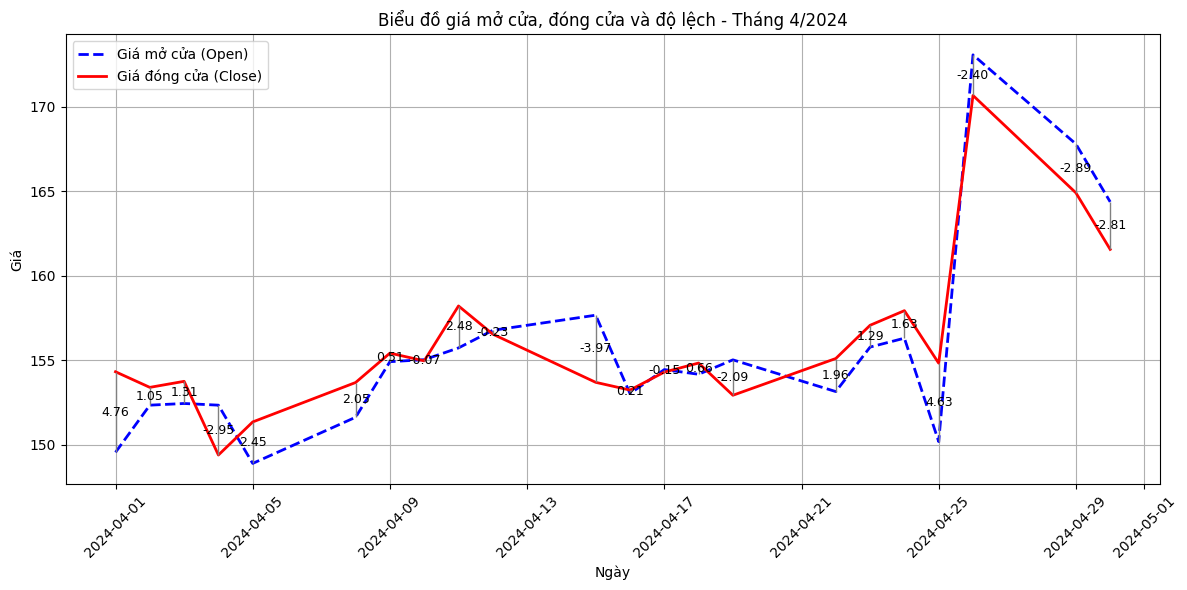

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu từ file Excel
data = pd.read_csv('/content/GOOGL_stock.csv', skiprows=3)

data.columns = ['Date','Close','High','Low','Open','Volume']

# Chuyển đổi cột 'Date' sang định dạng datetime
data['Date'] = pd.to_datetime(data['Date'])

# Thiết lập cột 'Date' làm chỉ mục cho DataFrame
data.set_index('Date', inplace=True)

# Kiểm tra dữ liệu thiếu và mô tả dữ liệu
print(data.describe())
print("Kiểm tra dữ liệu thiếu:\n", data.isnull().sum())
#Bước 2: Lọc dữ liệu theo tháng và Tính độ lệch giá
# Chọn tháng cần vẽ (ví dụ: tháng 4/2024)
year, month = 2024, 4
df_month = data.loc[f"{year}-{month:02d}"].copy()  # copy để tránh cảnh báo

# Kiểm tra dữ liệu sau khi lọc
if df_month.empty:
    print(f"Không có dữ liệu cho tháng {month}/{year}!")
else:
    # Tính độ lệch giá
    df_month['Price Diff'] = df_month['Close'] - df_month['Open']
    # Bước 3: Vẽ biểu đồ
    plt.figure(figsize=(12, 6))

    # Vẽ giá mở cửa và đóng cửa
    plt.plot(df_month.index, df_month['Open'], label='Giá mở cửa (Open)', color='blue', linestyle='--', linewidth=2)
    plt.plot(df_month.index, df_month['Close'], label='Giá đóng cửa (Close)', color='red', linestyle='-', linewidth=2)

    # Vẽ đường nối giữa giá mở cửa và giá đóng cửa (vlines)
    plt.vlines(df_month.index, df_month['Open'], df_month['Close'], color='gray', linestyle='-', linewidth=1)

    # Hiển thị giá trị độ lệch trên từng đường nối
    for date, open_price, close_price, diff in zip(df_month.index, df_month['Open'], df_month['Close'], df_month['Price Diff']):
        plt.text(date, (open_price + close_price) / 2, f"{diff:.2f}", color='black', fontsize=9, ha='center', va='center')

    # Định dạng biểu đồ
    plt.title(f'Biểu đồ giá mở cửa, đóng cửa và độ lệch - Tháng {month}/{year}')
    plt.xlabel('Ngày')
    plt.ylabel('Giá')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Hiển thị biểu đồ
    plt.show()

In [16]:
#Kiểm tra dữ liệu thiếu
# Kiểm tra các giá trị NaN trong chuỗi thời gian (ts)
print("\nKiểm tra dữ liệu thiếu:")
print(ts.isna().sum())

#Xử lý ngoại lệ (dùng IQR)
#Phương pháp Interquartile Range (IQR) giúp xác định các điểm dữ liệu bất thường (outliers) nằm ngoài phạm vi biến động thông thường.

# Tính toán các giá trị phân vị
Q1 = ts.quantile(0.25)
Q3 = ts.quantile(0.75)
IQR = Q3 - Q1

# Xác định ngưỡng dưới và ngưỡng trên
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc ra các giá trị ngoại lệ
outliers = ts[(ts < lower_bound) | (ts > upper_bound)]
print("\nSố lượng ngoại lệ (dựa trên IQR):", len(outliers))

#7.3 Biến đổi Log: Biến đổi Logarit thường được dùng để giảm sự thay đổi về phương sai (heteroscedasticity) và làm cho chuỗi dữ liệu ổn định hơn.
# Thực hiện log transform để ổn định phương sai
ts_log = np.log(ts)


Kiểm tra dữ liệu thiếu:
0

Số lượng ngoại lệ (dựa trên IQR): 105


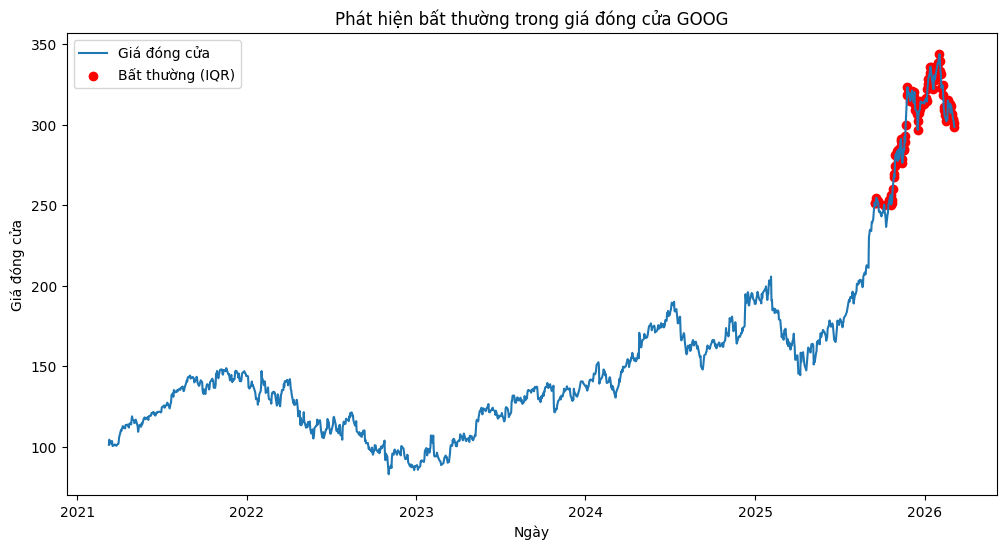

In [17]:
#Phát hiện bất thường (Anomaly Detection)
#Dùng IQR để phát hiện bất thường

# Xác định các điểm dữ liệu nằm ngoài ngưỡng lower_bound và upper_bound
ts_anomalies = ts[(ts < lower_bound) | (ts > upper_bound)]

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ đường biểu diễn giá đóng cửa thông thường
plt.plot(ts, label='Giá đóng cửa')

# Đánh dấu các điểm bất thường bằng các chấm đỏ (scatter plot)
plt.scatter(ts_anomalies.index, ts_anomalies, color='red', label='Bất thường (IQR)')

# Thêm các thông tin chú giải cho biểu đồ
plt.title('Phát hiện bất thường trong giá đóng cửa GOOG')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa')
plt.legend()

# Hiển thị biểu đồ
plt.show()

Resample – Lấy mẫu lại theo tháng:

Chuyển đổi tần suất của chuỗi thời gian :Từ dữ liệu hàng ngày --> trung bình theo tháng.

-->Giúp đơn giản hóa dữ liệu, loại bỏ các biến động nhiễu ngắn hạn và làm rõ xu hướng dài hạn.

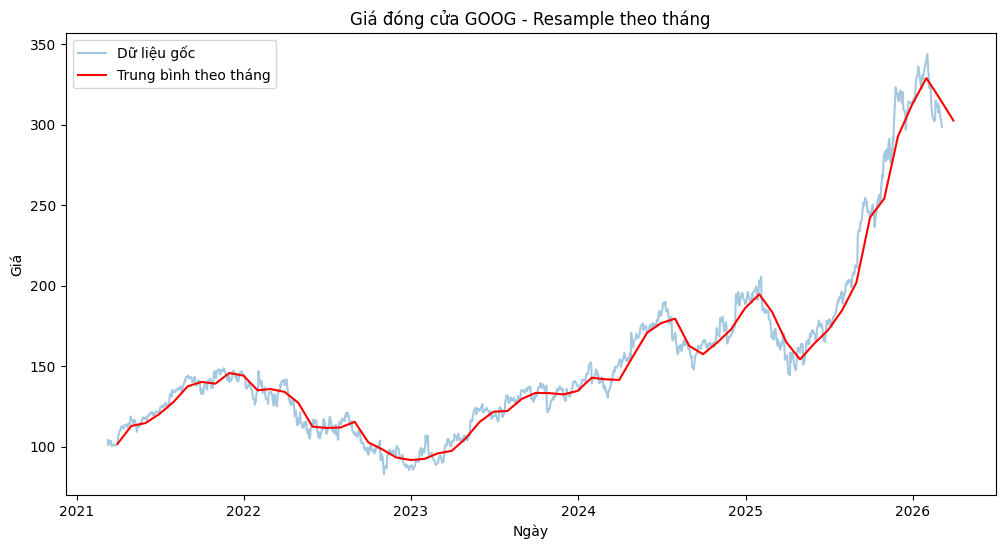

In [18]:
# Trung bình theo tháng
ts_monthly = ts.resample('M').mean()

plt.figure(figsize=(12, 6))
plt.plot(ts, alpha=0.4, label='Dữ liệu gốc')
plt.plot(ts_monthly, color='red', label='Trung bình theo tháng')
plt.title('Giá đóng cửa GOOG - Resample theo tháng')
plt.xlabel('Ngày')
plt.ylabel('Giá')
plt.legend()
plt.show()

Rolling Mean (Moving Average) – Trung bình trượt

Tính trung bình của một "cửa sổ" dữ liệu di động (moving window)

Làm mượt dữ liệu để loại bỏ nhiễu ngắn hạn.

Dữ liệu đầu tiên:
        Date       Close        High         Low        Open    Volume
0 2021-03-10  101.046036  102.297081  100.209355  102.297081  27100000
1 2021-03-11  104.239395  104.771871  102.051429  102.139266  27702000
2 2021-03-12  101.731346  103.101494  100.858940  103.041947  33818000
3 2021-03-15  101.951675  101.978966  100.629171  101.482223  26168000
4 2021-03-16  103.413147  104.891472  102.192367  102.524854  31900000


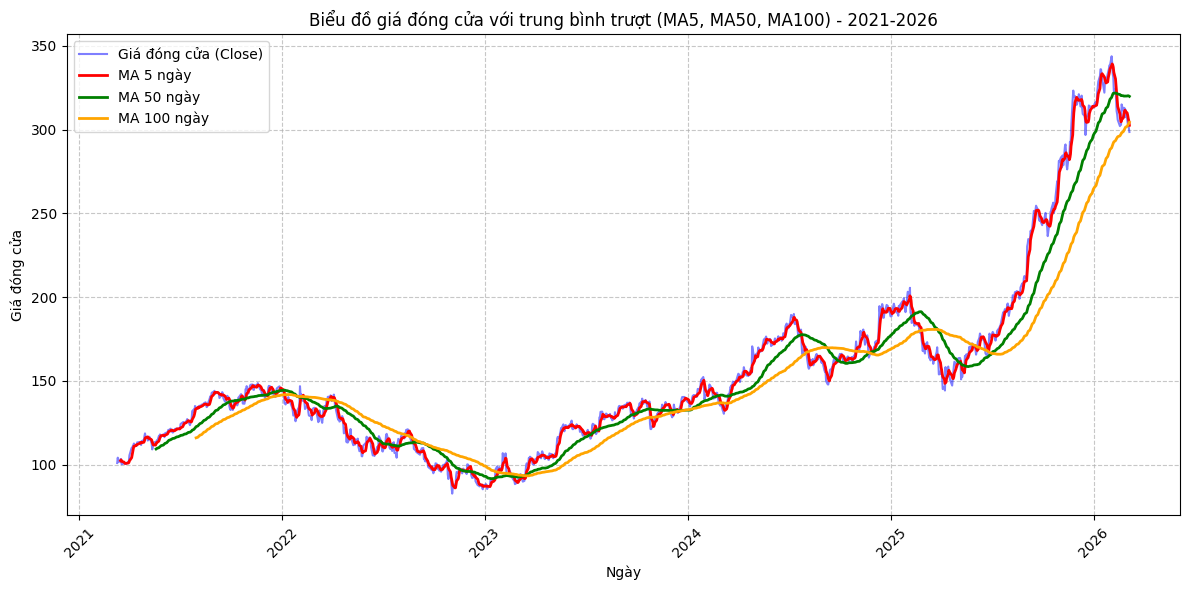

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu từ file Excel
data = pd.read_csv('/content/GOOGL_stock.csv', skiprows=3)
data.columns = ['Date','Close','High','Low','Open','Volume']
# Chuyển đổi cột 'Date' sang định dạng datetime
data['Date'] = pd.to_datetime(data['Date'])

# Kiểm tra dữ liệu
print(f"Dữ liệu đầu tiên:\n{data.head()}")

# Chọn cột Close để phân tích
ts = data['Close']

# Tính trung bình trượt (Moving Average)
ma_5 = ts.rolling(window=5).mean()    # MA 5 ngày
ma_50 = ts.rolling(window=50).mean()  # MA 50 ngày
ma_100 = ts.rolling(window=100).mean()# MA 100 ngày

# Bước 2: Phân tích khám phá dữ liệu (EDA)
# Vẽ biểu đồ giá đóng cửa với MA
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], ts, label='Giá đóng cửa (Close)', color='blue', alpha=0.5)
plt.plot(data['Date'], ma_5, label='MA 5 ngày', color='red', linewidth=2)
plt.plot(data['Date'], ma_50, label='MA 50 ngày', color='green', linewidth=2)
plt.plot(data['Date'], ma_100, label='MA 100 ngày', color='orange', linewidth=2)
plt.title('Biểu đồ giá đóng cửa với trung bình trượt (MA5, MA50, MA100) - 2021-2026')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Smoothing – Làm mượt bằng Exponential Moving Average (EMA)

Giảm nhiễu (noise), tập trung vào xu hướng chính.

Giống rolling mean nhưng trọng số giảm dần theo thời gian: càng gần hiện tại thì trọng số càng cao.

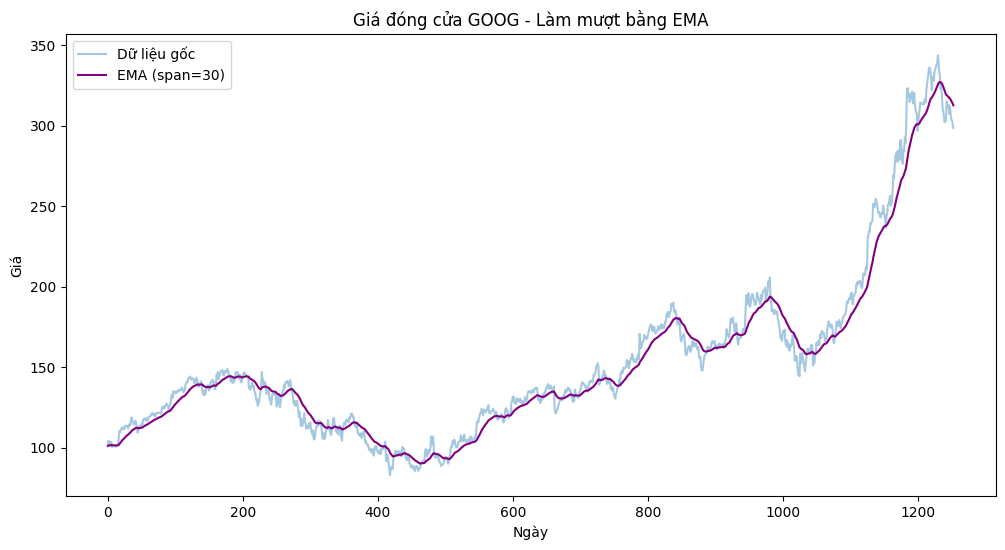

In [20]:
# EMA với span=30
ts_ema = ts.ewm(span=30, adjust=False).mean()

plt.figure(figsize=(12, 6))
plt.plot(ts, alpha=0.4, label='Dữ liệu gốc')
plt.plot(ts_ema, color='purple', label='EMA (span=30)')
plt.title('Giá đóng cửa GOOG - Làm mượt bằng EMA')
plt.xlabel('Ngày')
plt.ylabel('Giá')
plt.legend()
plt.show()